## Imports

In [42]:
import pandas as pd
import time
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import matthews_corrcoef, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

## PreProcess

In [43]:
RS = 678723
data = pd.read_csv("../../data/processed/final_dataset.csv")

feature_cols = [
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'loudness', 'duration_sec', 'popularity'
]

X = data[feature_cols]
y = data['macro_genre']
genres = data['macro_genre'].unique()

X.head()
# y.head()
print(genres)

['Acoustic' 'Hip-Hop' 'Rock' 'Metal' 'Folk' 'Electronic' 'Pop' 'Latin'
 'Jazz']


In [44]:
le = LabelEncoder()
y_labels = le.fit_transform(y)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_labels, test_size=0.25, random_state=RS, stratify=y_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=RS, stratify=y_train_val
)

# scaling: fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# DTree

In [45]:
def DTree_tune(X_train, X_val, y_train, y_val, random_state, max_depth_list):
    val_mcc = {}
    val_acc = {}
    best_depth = None
    best_val_mcc = -np.inf
    best_model = None

    for depth in max_depth_list:
        start_time = time.perf_counter()

        if depth == 0:
            dtc = DecisionTreeClassifier(
                criterion='entropy',
                random_state=random_state
            )
        else:
            dtc = DecisionTreeClassifier(
                criterion='entropy',
                max_depth=depth,
                random_state=random_state
            )

        dtc.fit(X_train, y_train)
        y_pred = dtc.predict(X_val)

        mcc = matthews_corrcoef(y_val, y_pred)
        acc = accuracy_score(y_val, y_pred)

        val_mcc[depth] = mcc
        val_acc[depth] = acc

        if mcc > best_val_mcc:
            best_val_mcc = mcc
            best_depth = depth
            best_model = dtc


        elapsed = time.perf_counter() - start_time
        print(f"depth={depth} mcc={mcc:.4f} acc={acc:.4f} time={elapsed:.4f}s")

    return val_mcc, val_acc, best_model, best_depth

max_depth = [0, 2, 4, 6, 8, 10, 15, 20]
val_mcc, val_acc, best_model, best_depth = DTree_tune(
    X_train_scaled, X_val_scaled, y_train, y_val, RS, max_depth
)

depth=0 mcc=0.3568 acc=0.4455 time=12.6293s
depth=2 mcc=0.3236 acc=0.4078 time=1.1711s
depth=4 mcc=0.3631 acc=0.4541 time=2.2921s
depth=6 mcc=0.3961 acc=0.4870 time=3.2027s
depth=8 mcc=0.4225 acc=0.5067 time=4.2350s
depth=10 mcc=0.4415 acc=0.5218 time=5.6454s
depth=15 mcc=0.4404 acc=0.5194 time=9.0491s
depth=20 mcc=0.3816 acc=0.4673 time=11.7809s


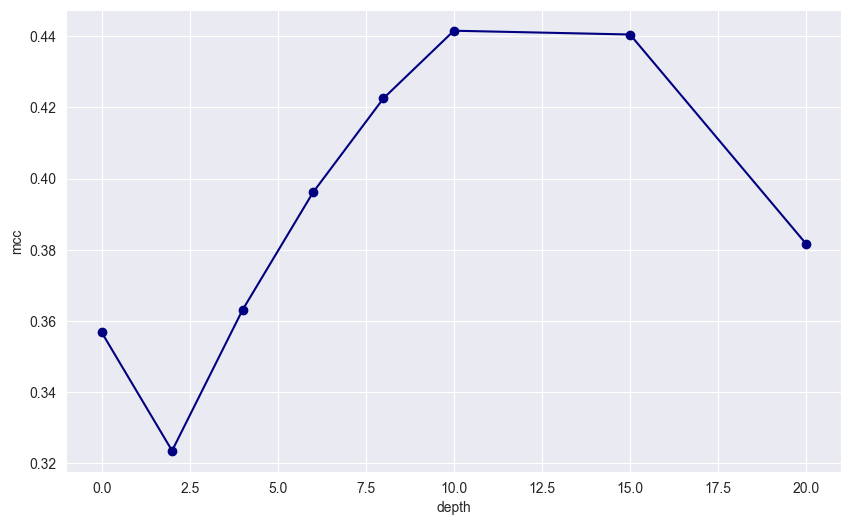

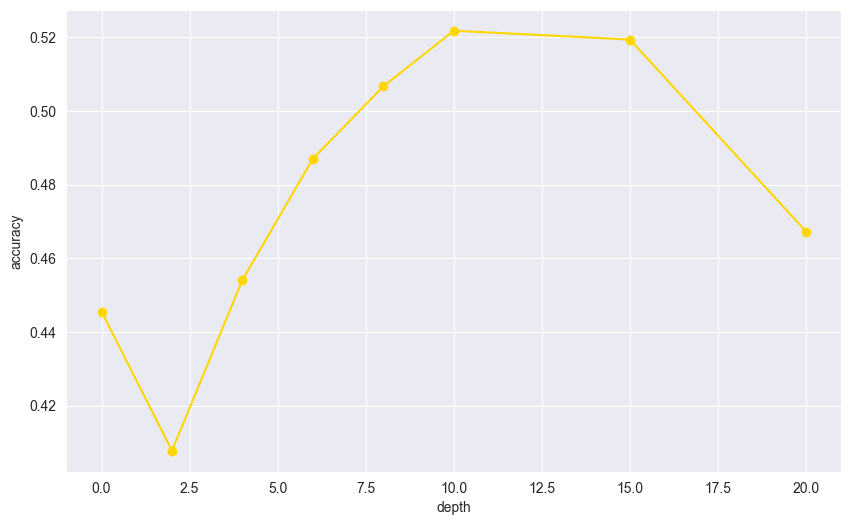

In [46]:
## DT MCC SCORE
fig = (10, 6)

plt.figure(figsize=fig)
plt.plot(max_depth, list(val_mcc.values()), marker="o", color="navy")
plt.xlabel("depth")
plt.ylabel("mcc")
plt.show()


plt.figure(figsize=fig)
plt.plot(max_depth, list(val_acc.values()), marker="o", color="gold")
plt.xlabel("depth")
plt.ylabel("accuracy")

plt.show()

In [47]:
X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

if best_depth == 0:
    final_model = DecisionTreeClassifier(criterion='entropy', random_state=RS)
else:
    final_model = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=RS)

final_model.fit(X_train_full, y_train_full)

y_test_pred = final_model.predict(X_test_scaled)
test_mcc = matthews_corrcoef(y_test, y_test_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Selected best_depth =", best_depth, "val_mcc =", val_mcc[best_depth])
print("Test MCC:", test_mcc)
print("Test Accuracy:", test_acc)
print("Classification report on test set:\n", classification_report(y_test, y_test_pred, zero_division=0))

Selected best_depth = 10 val_mcc = 0.44150734843542616
Test MCC: 0.4382703656847389
Test Accuracy: 0.5194138732012854
Classification report on test set:
               precision    recall  f1-score   support

           0       0.65      0.68      0.67     40886
           1       0.60      0.69      0.64     61763
           2       0.24      0.18      0.20     13434
           3       0.40      0.31      0.35     21091
           4       0.35      0.12      0.18      9391
           5       0.45      0.56      0.50     26818
           6       0.61      0.62      0.61     37999
           7       0.41      0.41      0.41     30382
           8       0.35      0.30      0.32     27734

    accuracy                           0.52    269498
   macro avg       0.45      0.43      0.43    269498
weighted avg       0.51      0.52      0.51    269498



# Decision Tree with smote

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RS)
X_train_rs, y_train_rs = smote.fit_resample(X_train_scaled, y_train)


max_depth = [0, 2, 4, 6, 8, 10, 15, 20]
val_mcc, val_acc, best_model, best_depth = DTree_tune(
    X_train_rs, X_val_scaled, y_train_rs, y_val, RS, max_depth
)


depth=0 mcc=0.3556 acc=0.4384 time=39.8965s
depth=2 mcc=0.3114 acc=0.3763 time=4.3762s
depth=4 mcc=0.3187 acc=0.3875 time=9.1260s
depth=6 mcc=0.3687 acc=0.4368 time=13.3370s
depth=8 mcc=0.3958 acc=0.4588 time=17.3370s
depth=10 mcc=0.4154 acc=0.4811 time=21.7699s
depth=15 mcc=0.4206 acc=0.4864 time=31.2990s
depth=20 mcc=0.3783 acc=0.4542 time=44.6374s


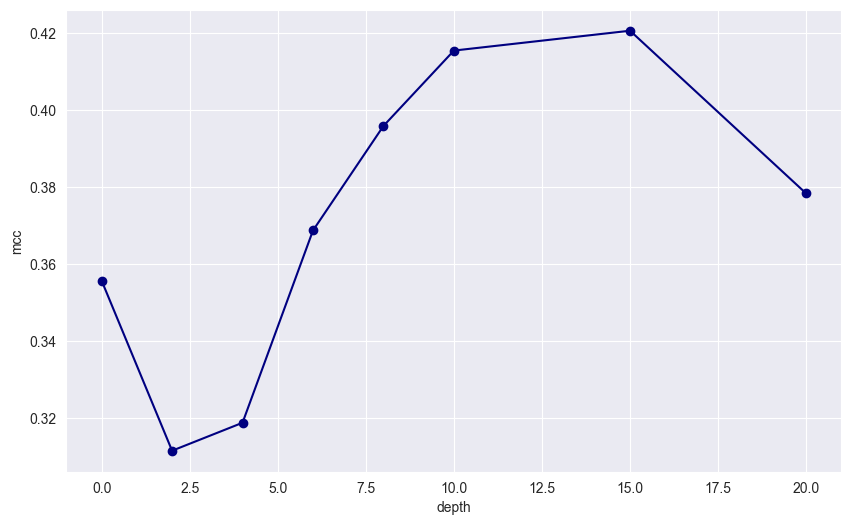

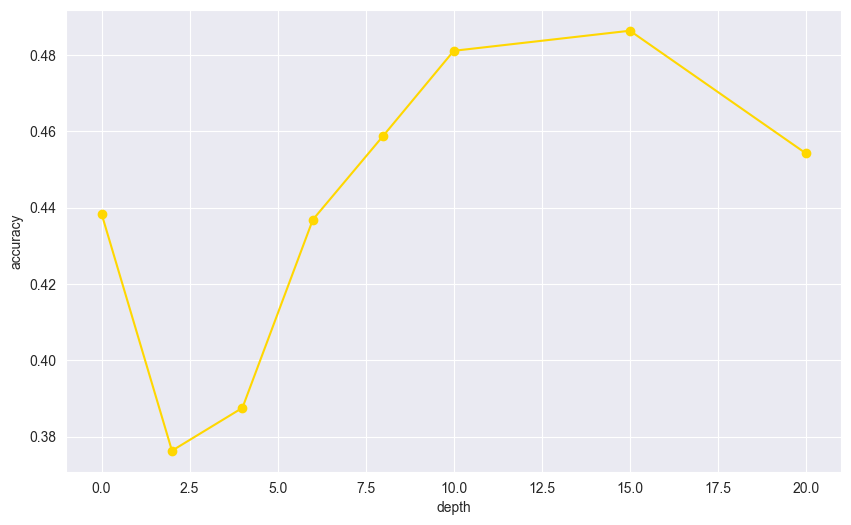

In [49]:
## DT MCC SCORE
fig = (10, 6)

plt.figure(figsize=fig)
plt.plot(max_depth, list(val_mcc.values()), marker="o", color="navy")
plt.xlabel("depth")
plt.ylabel("mcc")
plt.show()


plt.figure(figsize=fig)
plt.plot(max_depth, list(val_acc.values()), marker="o", color="gold")
plt.xlabel("depth")
plt.ylabel("accuracy")

plt.show()

In [51]:
X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

if best_depth == 0:
    final_model = DecisionTreeClassifier(criterion='entropy', random_state=RS)
else:
    final_model = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=RS)

X_train_full_res, y_train_full_res = smote.fit_resample(X_train_full, y_train_full)
final_model.fit(X_train_full_res, y_train_full_res)

y_test_pred = final_model.predict(X_test_scaled)
test_mcc = matthews_corrcoef(y_test, y_test_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Selected best_depth =", best_depth, "val_mcc =", val_mcc[best_depth])
print("Test MCC:", test_mcc)
print("Test Accuracy:", test_acc)
print("Classification report on test set:\n", classification_report(y_test, y_test_pred, zero_division=0))

Selected best_depth = 15 val_mcc = 0.42057032154757795
Test MCC: 0.42579834023500424
Test Accuracy: 0.49066783426964206
Classification report on test set:
               precision    recall  f1-score   support

           0       0.76      0.58      0.66     40886
           1       0.77      0.50      0.61     61763
           2       0.21      0.50      0.30     13434
           3       0.32      0.45      0.38     21091
           4       0.19      0.42      0.26      9391
           5       0.50      0.53      0.52     26818
           6       0.61      0.61      0.61     37999
           7       0.47      0.36      0.41     30382
           8       0.35      0.32      0.33     27734

    accuracy                           0.49    269498
   macro avg       0.46      0.48      0.45    269498
weighted avg       0.56      0.49      0.51    269498

